# **Data Preparation**

### **Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeon.datasets import load_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


### **Load Dataset**

In [2]:
X_train, y_train = load_classification(
    name="DucksAndGeese",
    split="train",
    extract_path="../data",
    load_equal_length=False
)

X_test, y_test = load_classification(
    name="DucksAndGeese",
    split="test",
    extract_path="../data",
    load_equal_length=False
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (50, 1, 236784)
Test shape : (50, 1, 236784)


### **Verifikasi Tidak Ada Missing Value**

In [3]:
print("NaN di X_train:", np.isnan(X_train).sum())
print("NaN di X_test :", np.isnan(X_test).sum())


NaN di X_train: 0
NaN di X_test : 0


### **Visualisasi Sebelum & Sesudah Normalisasi**

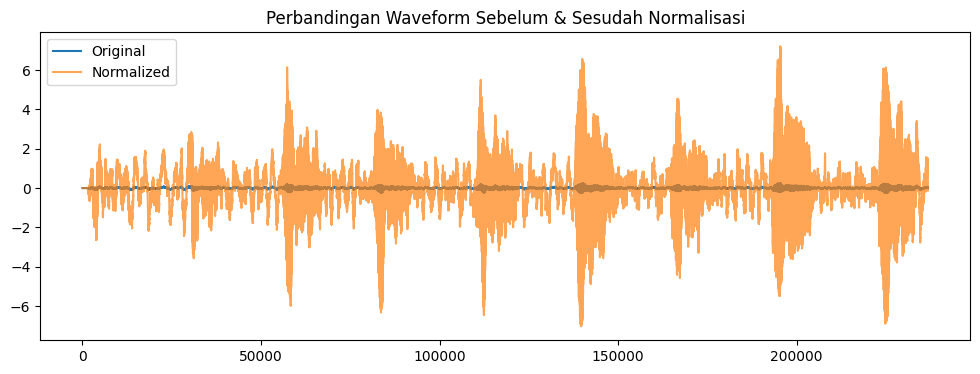

In [11]:
plt.figure(figsize=(12,4))
plt.plot(X_train[0][0], label="Original")
plt.plot(X_train_norm[0][0], label="Normalized", alpha=0.7)
plt.legend()
plt.title("Perbandingan Waveform Sebelum & Sesudah Normalisasi")
plt.show()


### **Split Train = Train & Validation**
Split 80% train – 20% validation

In [12]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Train final :", X_tr.shape)
print("Validation  :", X_val.shape)


Train final : (40, 1, 236784)
Validation  : (10, 1, 236784)


### **Verifikasi Distribusi Kelas Setelah Split**

In [13]:
def print_distribution(y, title):
    labels, counts = np.unique(y, return_counts=True)
    print(title)
    for l, c in zip(labels, counts):
        print(f"{l}: {c}")
    print()

print_distribution(y_tr, "Distribusi Train")
print_distribution(y_val, "Distribusi Validation")
print_distribution(y_test, "Distribusi Test")

Distribusi Train
black-bellied_whistling_duck: 8
canadian_goose: 8
greylag_goose: 8
pink-footed_goose: 8
white-faced_whistling_duck: 8

Distribusi Validation
black-bellied_whistling_duck: 2
canadian_goose: 2
greylag_goose: 2
pink-footed_goose: 2
white-faced_whistling_duck: 2

Distribusi Test
black-bellied_whistling_duck: 10
canadian_goose: 10
greylag_goose: 10
pink-footed_goose: 10
white-faced_whistling_duck: 10



### **3.1 Normalisasi Sinyal**

In [14]:
def zscore_normalize(signal):
    mean = np.mean(signal)
    std  = np.std(signal)
    return (signal - mean) / (std + 1e-8)

x = X_train[0][0]
x_norm = zscore_normalize(x)

print("Before:", np.mean(x), np.std(x))
print("After :", np.mean(x_norm), np.std(x_norm))

Before: 5.0382269563103935e-05 0.0357001264313538
After : 4.321159957997771e-18 0.9999997198890256


In [15]:
X_train_norm = np.array([
    zscore_normalize(x[0]) for x in X_train
]).reshape(X_train.shape)

X_test_norm = np.array([
    zscore_normalize(x[0]) for x in X_test
]).reshape(X_test.shape)

print("Normalisasi selesai")


Normalisasi selesai


### **3.2 *Downsampling***

In [16]:
import librosa

TARGET_SR = 16000
ORIGINAL_SR = 44100

x_ds = librosa.resample(
    x_norm,
    orig_sr=ORIGINAL_SR,
    target_sr=TARGET_SR
)

print("Length after downsampling:", len(x_ds))

Length after downsampling: 85909


### **3.3 *Feature Extraction***

| Fitur                | Jumlah | Deskripsi                    |
|----------------------|--------|------------------------------|
| MFCC                 | 13     | Karakteristik spektral suara |
| Zero Crossing Rate   | 1      | Kecepatan perubahan sinyal   |
| RMS Energy           | 1      | Intensitas suara             |
| Spectral Centroid    | 1      | Kecerahan suara              |


In [17]:
def extract_features(signal, sr=16000):
    features = []

    # MFCC
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)
    features.extend(mfcc_mean)

    # ZCR
    zcr = np.mean(librosa.feature.zero_crossing_rate(signal))
    features.append(zcr)

    # RMS
    rms = np.mean(librosa.feature.rms(y=signal))
    features.append(rms)

    # Spectral Centroid
    centroid = np.mean(librosa.feature.spectral_centroid(y=signal, sr=sr))
    features.append(centroid)

    return np.array(features)

feat = extract_features(x_ds)

print("Feature shape:", feat.shape)
print(feat)


Feature shape: (16,)
[-3.03277749e+01  4.00774343e+01  9.66616907e+01  6.28365968e+01
  4.14131158e+00  3.07694526e+01  1.42954671e+01 -1.71178020e+00
 -5.15671574e+00  9.42606799e+00 -2.54702141e+00 -6.32606819e+00
  1.37829476e+01  1.57386416e-01  9.18488979e-01  2.15745077e+03]


### **3.4 Ekstraksi fitur TRAIN untuk semua data**

In [19]:
X_feat = []
y_feat = []

for i in range(len(X_train)):
    signal = X_train[i][0]
    signal = zscore_normalize(signal)
    
    signal = librosa.resample(
        y=signal,
        orig_sr=44100,
        target_sr=16000
    )

    features = extract_features(signal)
    X_feat.append(features)
    y_feat.append(y_train[i])

X_feat = np.array(X_feat)
y_feat = np.array(y_feat)

print(X_feat.shape)

(50, 16)


### **3.5 Ekstraksi fitur TEST**

In [21]:
# Membuat array fitur dan label untuk TEST
X_feat_test = []
y_feat_test = []

for i in range(len(X_test)):
    signal = X_test[i][0]              # Ambil sinyal dari X_test
    signal = zscore_normalize(signal)  # Normalisasi z-score

    # Opsional resampling jika ingin disesuaikan dengan TRAIN
    signal = librosa.resample(
        y=signal,
        orig_sr=44100,
        target_sr=16000
    )

    # Ekstraksi fitur menggunakan fungsi extract_features yang sama
    features = extract_features(signal)
    X_feat_test.append(features)
    y_feat_test.append(y_test[i])

# Konversi ke numpy array
X_feat_test = np.array(X_feat_test)
y_feat_test = np.array(y_feat_test)

print(X_feat_test.shape)


(50, 16)


### **3.6 Train / Validation Split**

In [22]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_feat,          # fitur train hasil ekstraksi
    y_feat,          # label train
    test_size=0.2,
    random_state=42,
    stratify=y_feat  # agar distribusi kelas tetap seimbang
)

print("Train final shape:", X_train_final.shape)
print("Validation shape:", X_val.shape)

Train final shape: (40, 16)
Validation shape: (10, 16)


### **3.7 Standardisasi fitur**

In [25]:
scaler = StandardScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_feat_test)  # gunakan fitur test yang sudah diekstraksi


# Standardisasi fitur
mfcc_cols = [f"mfcc{i+1}" for i in range(13)]
feature_cols = mfcc_cols + ["zcr", "rms", "centroid"]  # total 16 fitur

df_train = pd.DataFrame(X_train_final_scaled, columns=feature_cols)
df_train["label"] = y_train_final

df_val = pd.DataFrame(X_val_scaled, columns=feature_cols)
df_val["label"] = y_val

df_test = pd.DataFrame(X_test_scaled, columns=feature_cols)
df_test["label"] = y_feat_test  # label test

print("Contoh data train:")
print(df_train.head())

Contoh data train:
      mfcc1     mfcc2     mfcc3     mfcc4     mfcc5     mfcc6     mfcc7  \
0  0.539017 -0.949161  1.135375  1.506132 -0.468704  0.307521  0.638655   
1  1.536679  0.590696  0.766747  0.328454  1.088302  0.394573  0.988120   
2  1.249843  0.026736 -1.330608 -0.372341  0.143090  0.854917 -1.300501   
3 -1.815987  1.304317  0.443364 -0.549747 -0.064497 -0.551112  0.180480   
4 -0.092758 -0.715671 -0.410989  0.848762  1.169403  0.183659 -0.326187   

      mfcc8     mfcc9    mfcc10    mfcc11    mfcc12    mfcc13       zcr  \
0 -0.051023  0.150237  1.269368 -0.861989  0.976513  1.703382  1.098734   
1  0.701457  0.052172 -0.311410 -0.089043 -0.002237 -0.250600 -0.399321   
2  0.579948  1.763459 -0.921161 -2.589722 -0.824911 -1.007694 -0.349004   
3 -0.417936 -0.823769 -1.508067 -0.899350 -1.356602 -0.996021 -1.119913   
4  0.476016 -0.212572 -0.855288 -0.422901 -0.297941 -0.764600  0.433529   

        rms  centroid                         label  
0  1.079191  1.223952  bl

### **Simpan fitur dan label**

In [26]:
import numpy as np
import os

os.makedirs("data/processed", exist_ok=True)

# Simpan fitur dan label
np.save("data/processed/X_train_final_scaled.npy", X_train_final_scaled)
np.save("data/processed/y_train_final.npy", y_train_final)

np.save("data/processed/X_val_scaled.npy", X_val_scaled)
np.save("data/processed/y_val.npy", y_val)

np.save("data/processed/X_test_scaled.npy", X_test_scaled)
np.save("data/processed/y_test.npy", y_feat_test)
